# Tutorial: Solving Rule-Compliant Trajectory Repairing Problems
This tutorial demonstrates how we can use the existing trajectory repairing framework to solve real planning problems that the initially-planned trajectory is not rule-compliant

## 0. Preparation
Before you proceed with this tutorial, make sure that

* you have gone through the tutorials on **CommonRoad Input-Output**
* you have installed all necessary modules for **CommonRoad Repairer** according to the installation manual.

Let's start with importing relevant modules and classes for setting up the CommonRoad (CR) scenario.

In [1]:
% matplotlib inline
% load_ext autoreload
% autoreload 2

import os
path_notebook = os.getcwd()

# CommonRoad packages
from commonroad.common.file_reader import CommonRoadFileReader

from commonroad_repair.crrepairer.smt.monitor_wrapper import STLRuleMonitor
from commonroad_repair.crrepairer.repairer.smt_repairer import SMTTrajectoryRepairer

# add the root folder to python path
# sys.path.append(os.path.join(path_notebook, "../../"))

## 1. Loading CR Scenario and Planning Problem Set
In the next step, we load CommonRoad scenarios and their planning problems.

In [2]:
path_scenario = os.path.join(path_notebook, "../scenarios/")
id_scenario = 'DEU_Gar-1_1_T-1'

# read in scenario and planning problem set, lanelet_assignment needs to be True
scenario, planning_problem_set = CommonRoadFileReader(path_scenario + id_scenario + '.xml').open(
    lanelet_assignment=True)
# retrieve the first planning problem in the problem set
planning_problem = list(planning_problem_set.planning_problem_dict.values())[0]

## 2. Select the ego vehicle, whose initial trajectory violates traffic rules
We need to define the rule and the vehicle ID

In [3]:
ego_id = 200
rule = "R_G1"
# ego vehicle with the initially-planned trajectory
ego_initial = scenario.obstacle_by_id(ego_id)

## 3. Trajectory Repairing
### 3.1 Define the rule abstracter and initialize the trajectory repairing framework
We use the lazy SMT solver for our trajectory repairing problem. This method abstracts the input formula to a propositional one and feeds it to a SAT solver to suggest possible assignments. The T-solver checks the satisfiability of the obtained assignment in a theory T (T-consistency) to refine the formula and guide the SAT solver. Therefore, we need first to define the rule abstracter and then use it to initialize the trajectory repairing problem with the initially-planned trajectory.

In [5]:
rule_monitor = STLRuleMonitor(scenario,
                              planning_problem,
                              ego_id,
                              rule)
repairer = SMTTrajectoryRepairer(rule_monitor,
                                 ego_initial)

ANTLR runtime and generated code versions disagree: 4.8!=4.5.1
ANTLR runtime and generated code versions disagree: 4.8!=4.5.1
ANTLR runtime and generated code versions disagree: 4.8!=4.5.1
ANTLR runtime and generated code versions disagree: 4.8!=4.5.1
ANTLR runtime and generated code versions disagree: 4.8!=4.5.1
ANTLR runtime and generated code versions disagree: 4.8!=4.5.1
ANTLR runtime and generated code versions disagree: 4.8!=4.5.1
ANTLR runtime and generated code versions disagree: 4.8!=4.5.1


### 3.2 start repairing
1. find the cut-off state
2. use QP-planner to obtain the repaired trajectory

In [6]:
# call the repairing function
repaired_traj = repairer.repair()
# updated ego vehicle with the repaired trajectory
ego_vehicle = repairer.convert_traj_to_ego_vehicle(ego_initial.obstacle_shape,
                                                   ego_initial.initial_state,
                                                   repaired_traj)
# we use the existing CommonRoad vehicle models, thus, the vehicle dimension needs to be updated
ego_initial.prediction.shape = ego_vehicle.prediction.shape

<DPLL>: the robustness of instances in TV of alphabet c is -0.024914729782931806
<DPLL>: the robustness of instances in TV of alphabet d is -0.0026686044634478367
<DPLL>: the robustness of instances in TV of alphabet ~a is 0.11323200699357489
<DPLL>: the robustness of instances in TV of alphabet ~b is 0.06952187172702835
<DPLL>: the robustness of instances in TV of alphabet c is -0.024914729782931806
<DPLL>: the robustness of instances in TV of alphabet d is -0.0026686044634478367
<DPLL>: the robustness of instances in TV of alphabet ~a is 0.11323200699357489
<DPLL>: the robustness of instances in TV of alphabet ~b is 0.06952187172702835
<DPLL>: the robustness of instances in TV of alphabet c is -0.024914729782931806
<DPLL>: the robustness of instances in TV of alphabet d is -0.0026686044634478367
<DPLL>: the robustness of instances in TV of alphabet ~a is 0.11323200699357489
<DPLL>: the robustness of instances in TV of alphabet ~b is 0.06952187172702835
<SATSolver>: model is {'d'}
<TS

INFO:Route Planner [DEU_Gar-1_1_T-1]:Route planner started


<T-solver>: tc = 1.3, tv = 1.4
<QP planner>: process starts
	 Longitudinal optimization
<QPRepairer/_rule_constraints>: we cannot add constraints for cut in
Problem is convex: True
	 Lateral optimization
Problem is convex: True
                                     CVXPY                                     
                                    v1.1.15                                    
(CVXPY) Mar 30 10:54:16 AM: Your problem has 44 variables, 27 constraints, and 0 parameters.
(CVXPY) Mar 30 10:54:16 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 30 10:54:16 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 30 10:54:16 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
-------------------------------------------------------------------------------
                                  Compilation                                  
---------------

### 3.3 Visualize the result
1. initial configuration
2. repaired configuration

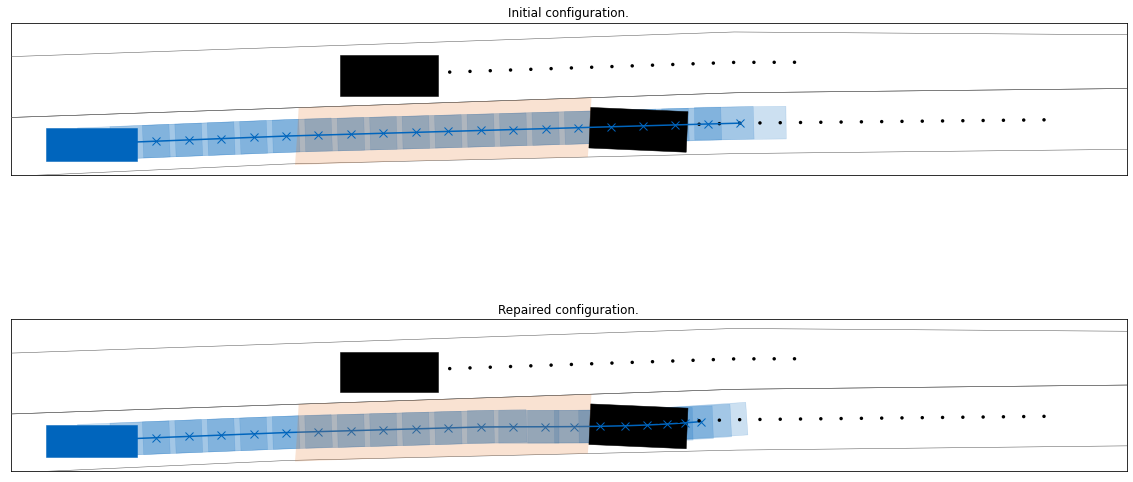

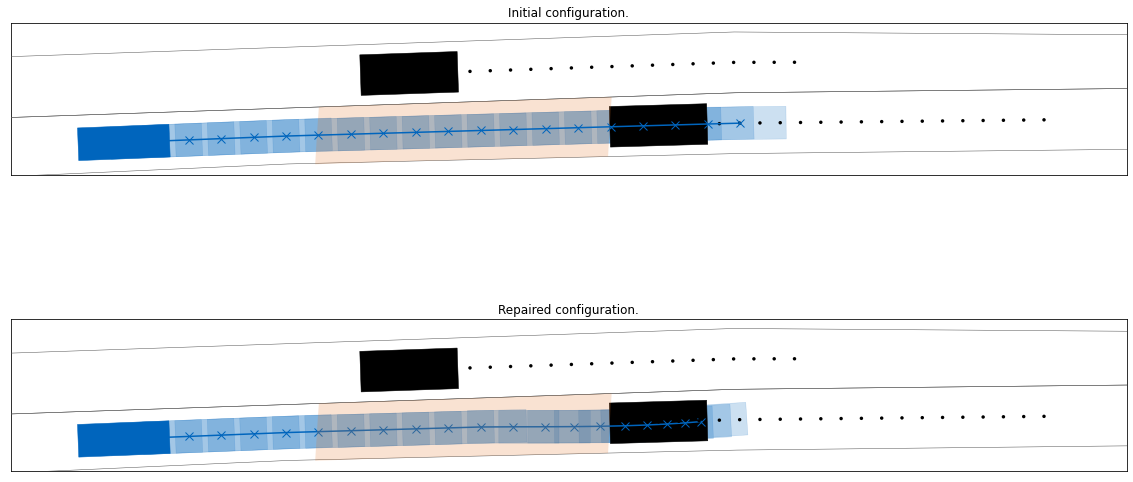

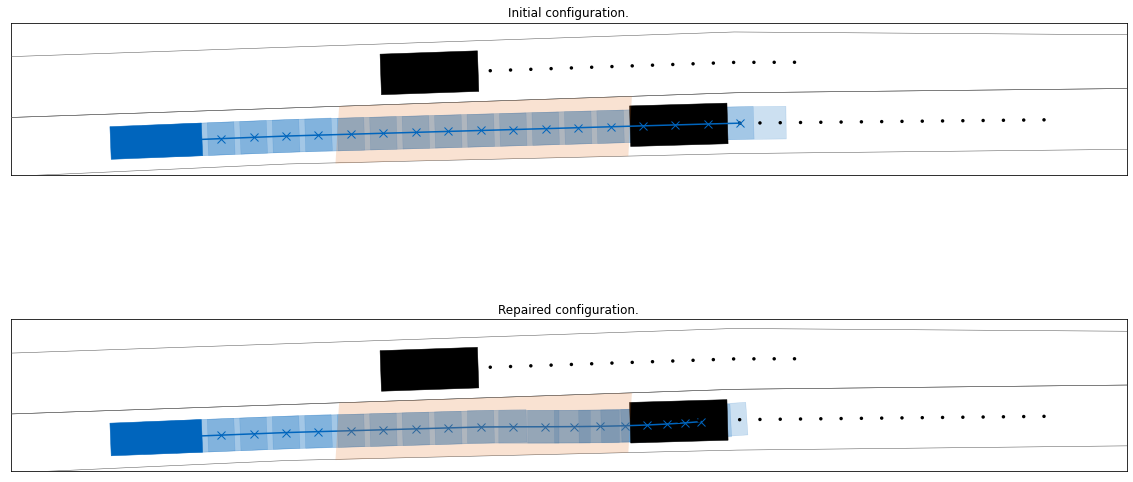

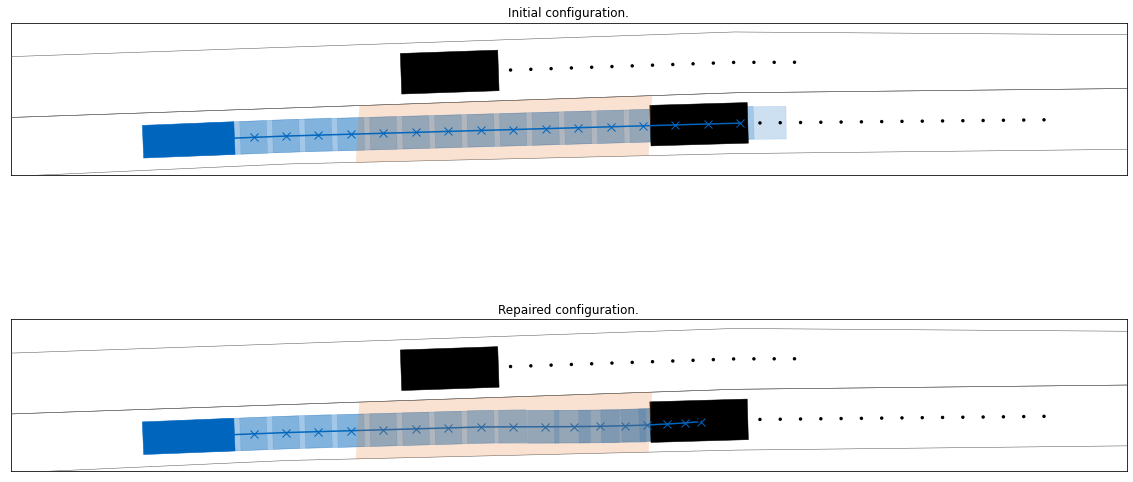

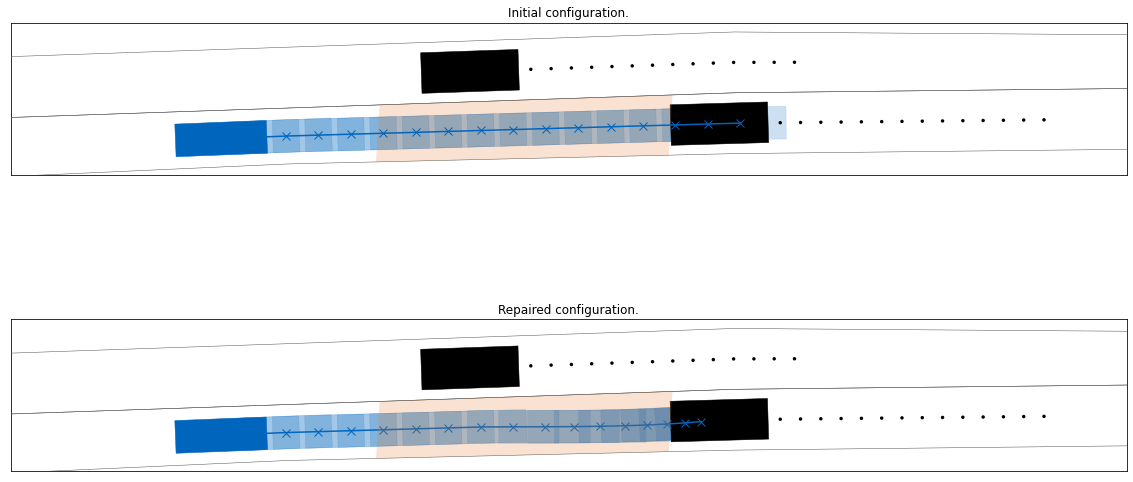

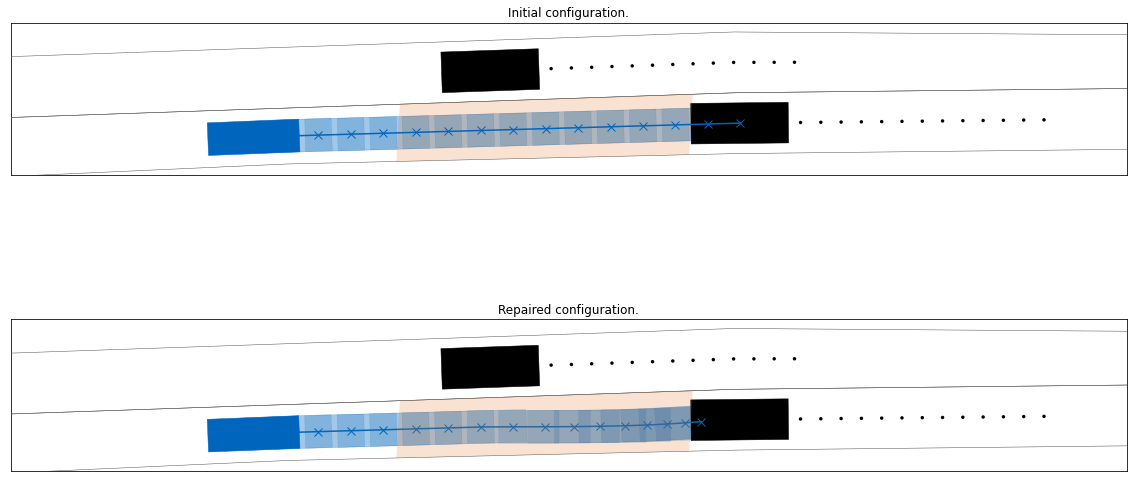

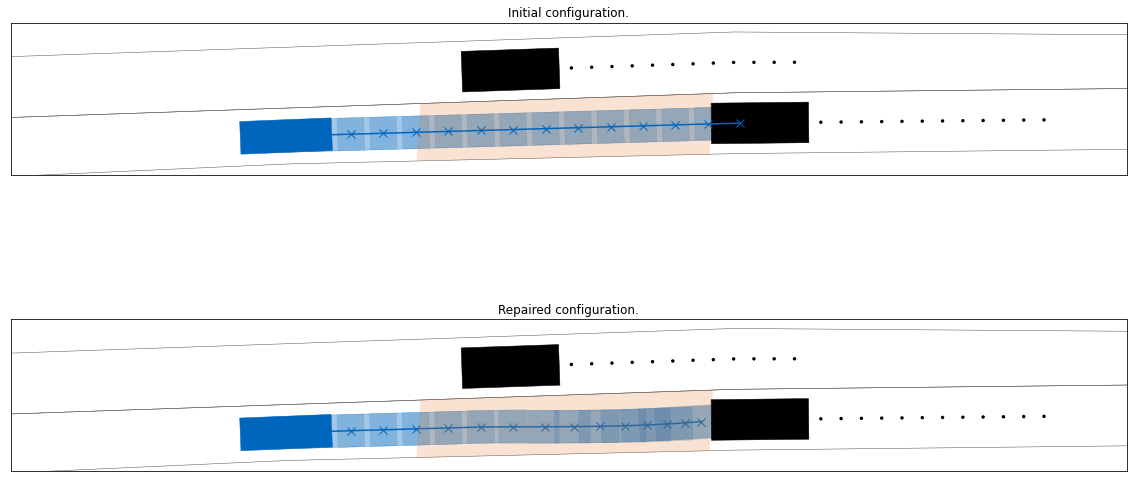

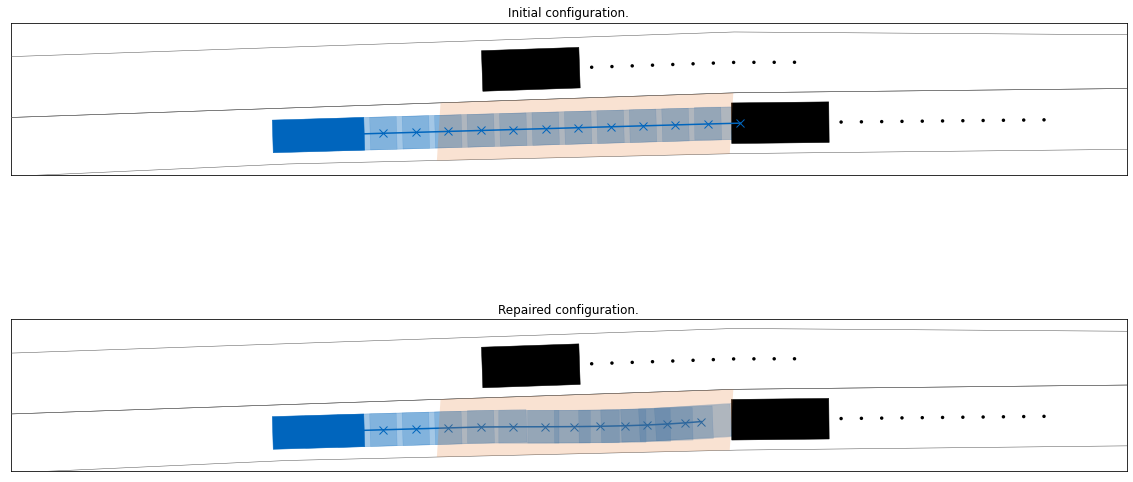

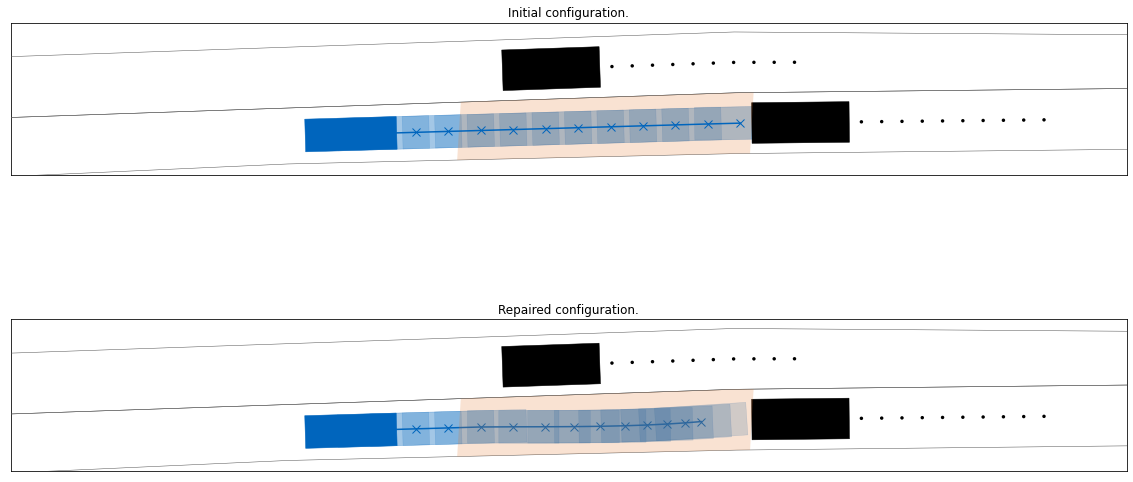

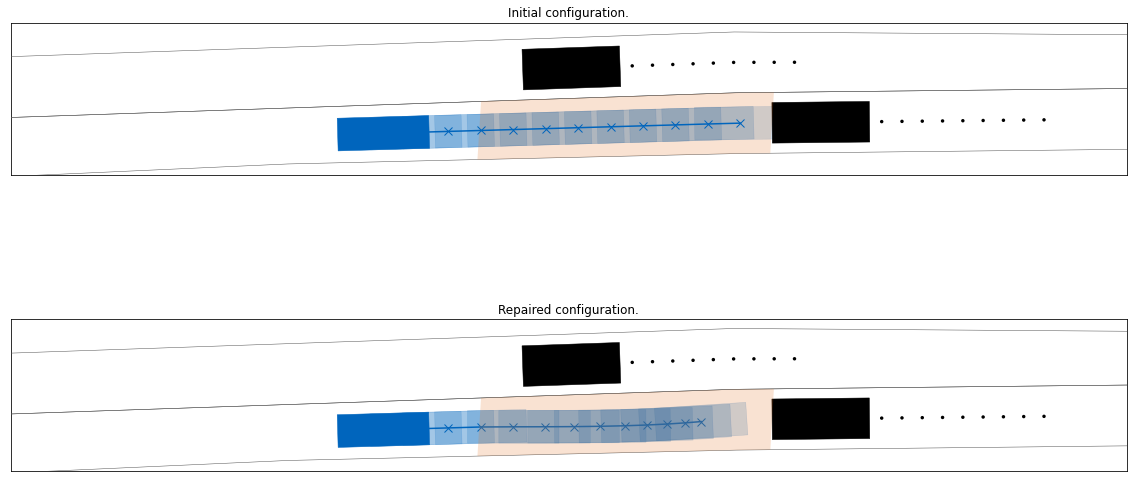

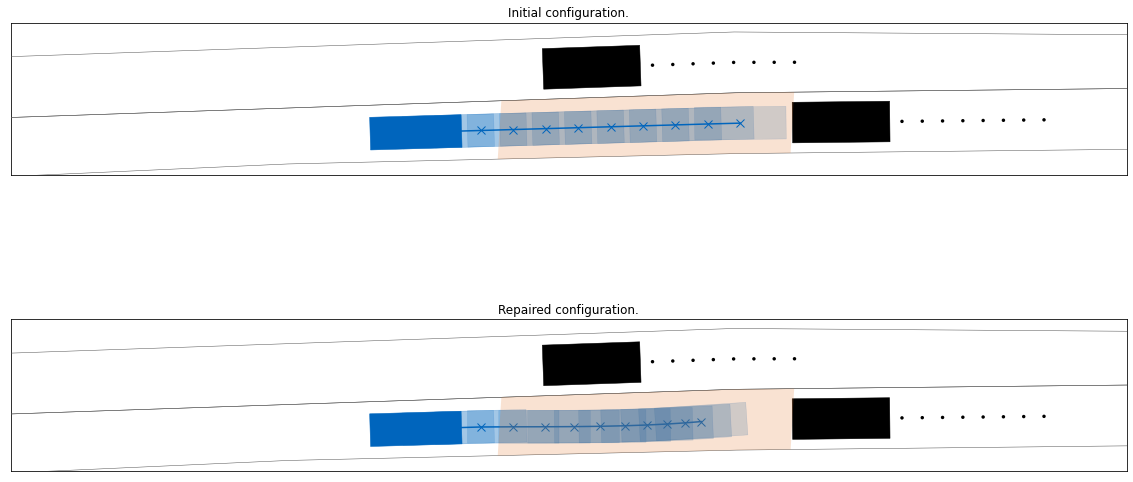

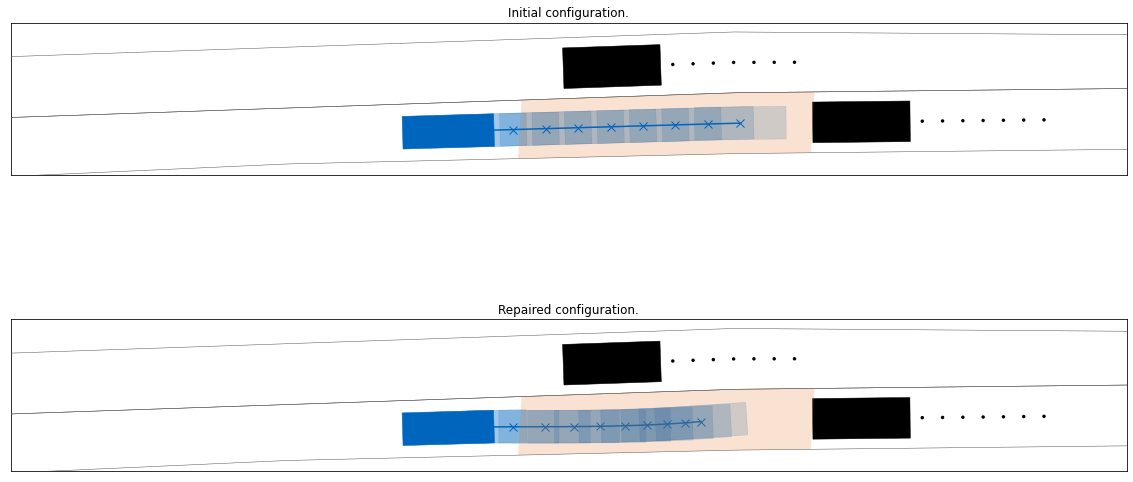

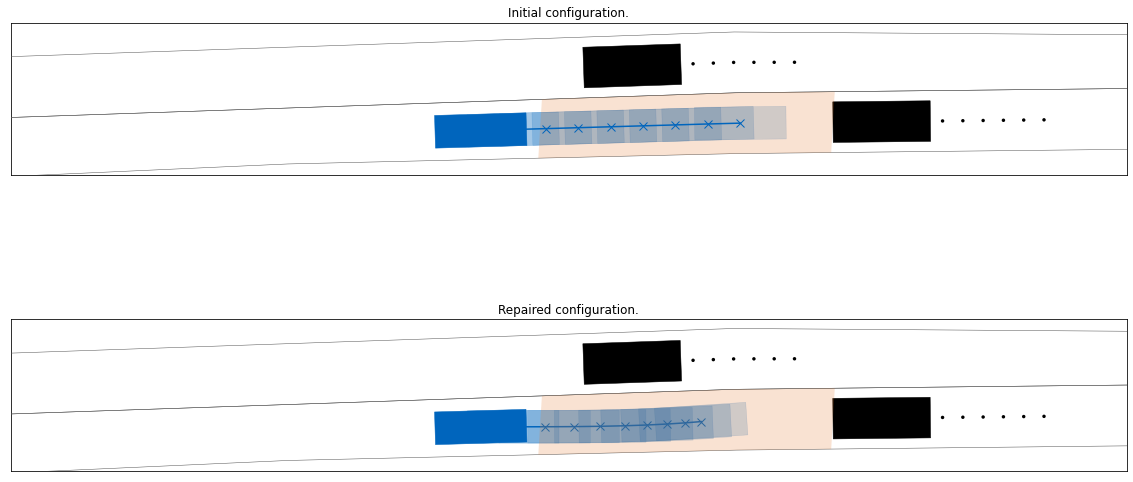

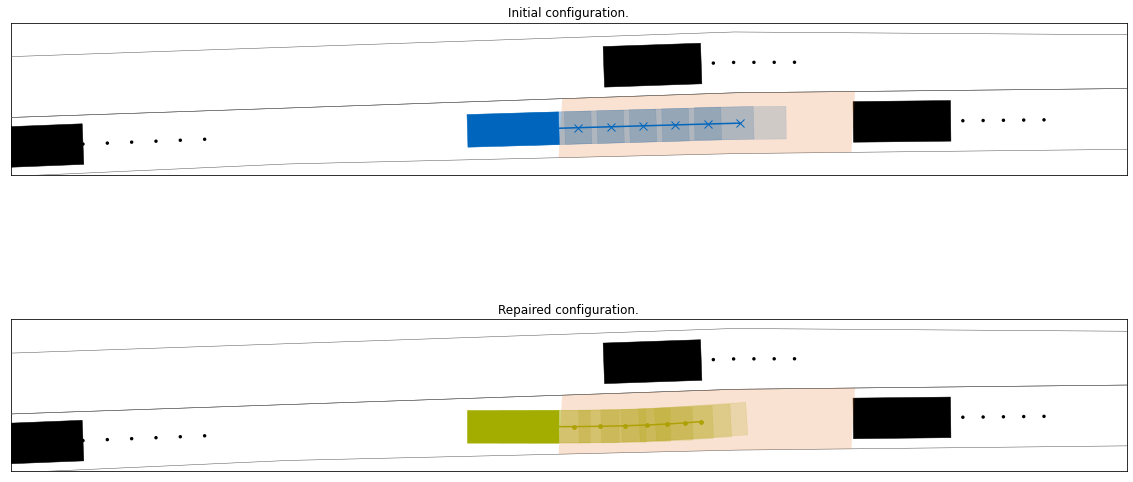

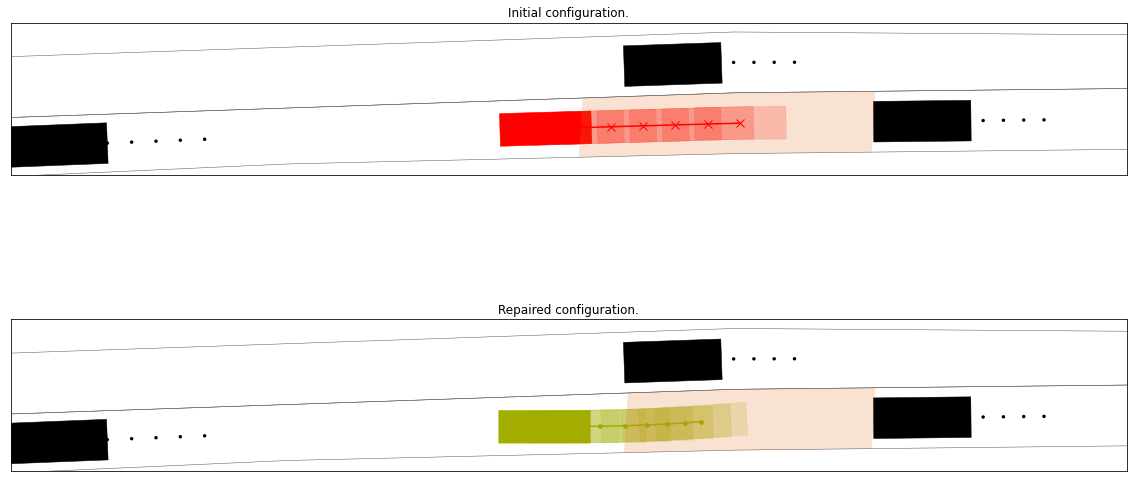

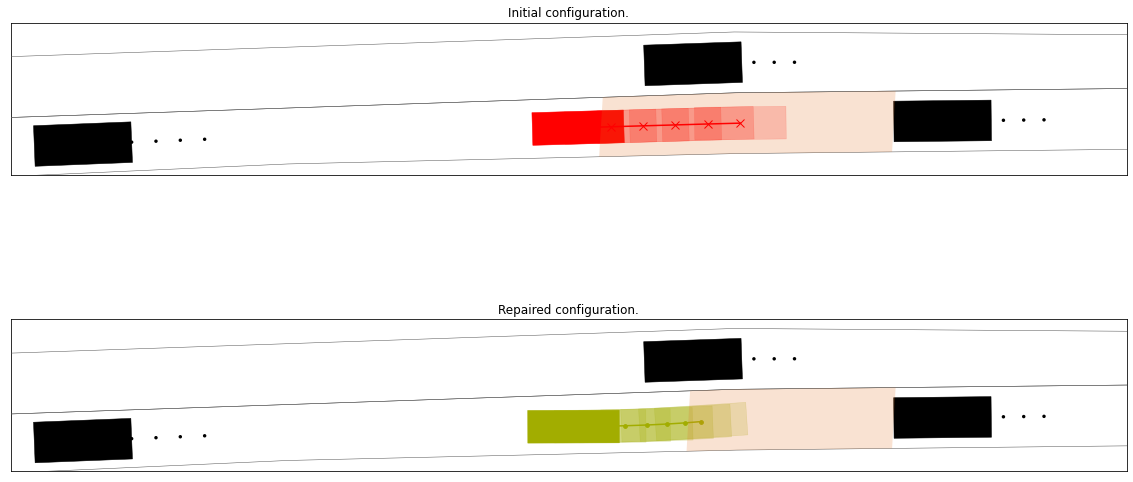

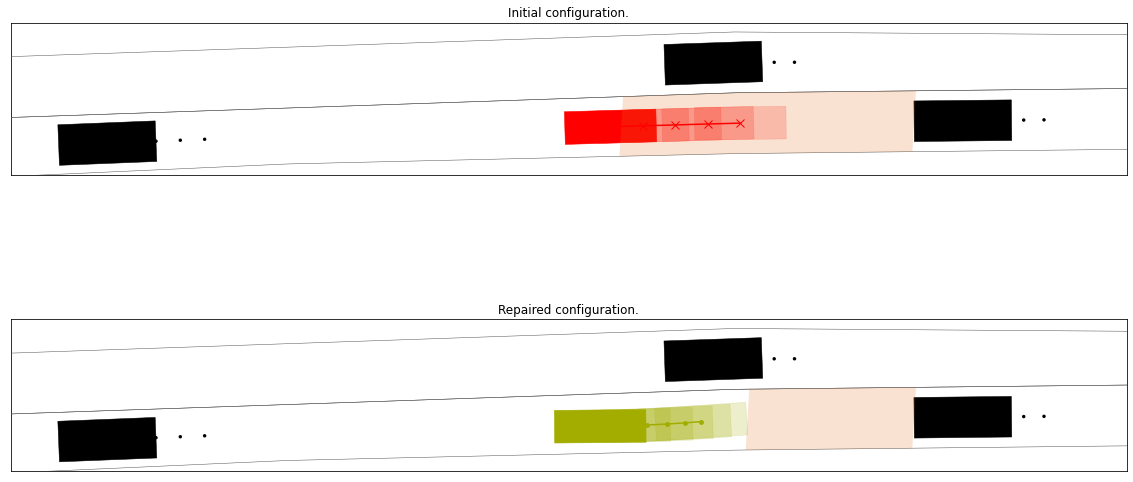

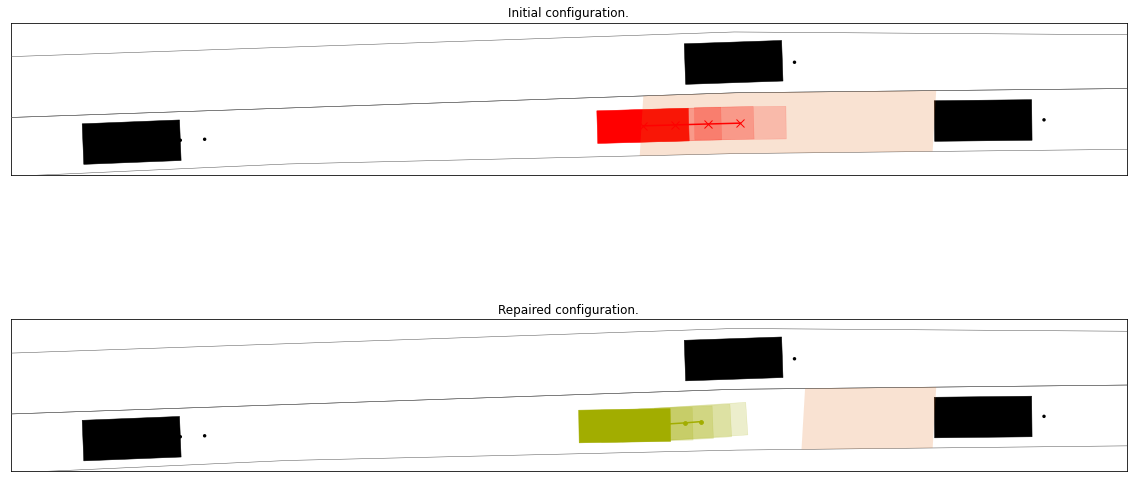

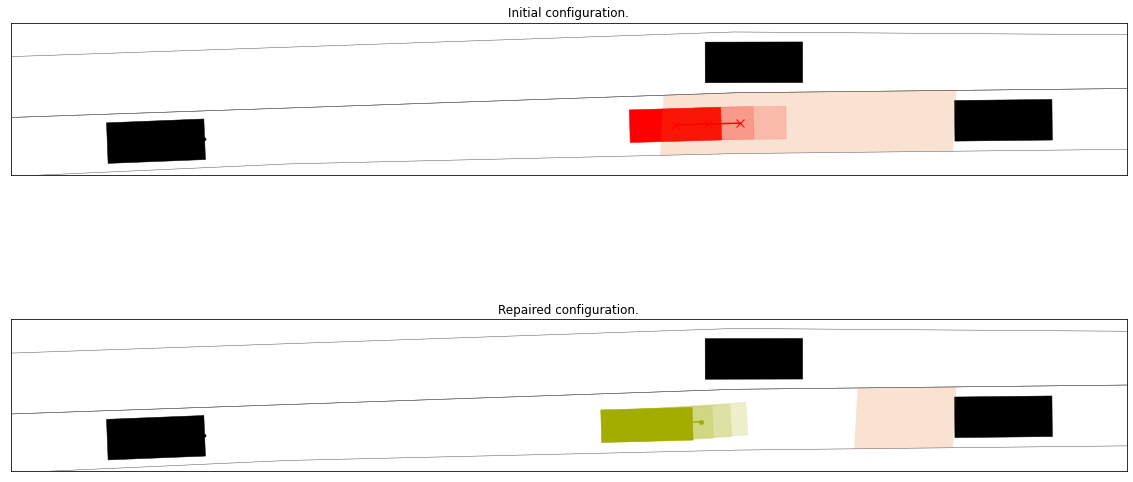

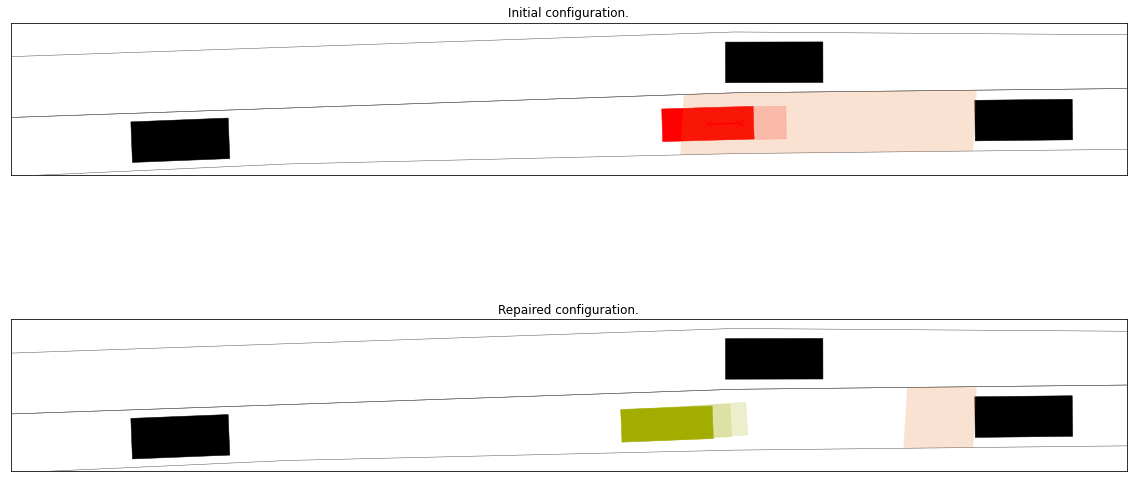

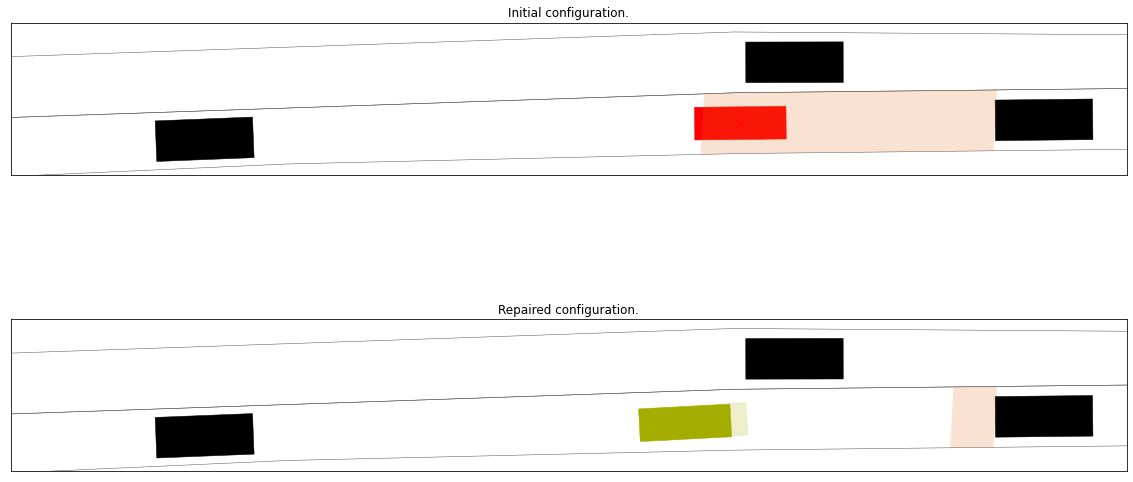

In [7]:
plot_limits = [-5, 50, -4.5, 3]

from commonroad_repair.crrepairer.repairer.visualization import visualize_repairing_result

for time_step in range(ego_initial.prediction.final_time_step + 1):
    visualize_repairing_result(scenario,
                               ego_initial,
                               ego_vehicle,
                               time_step,
                               tc=repairer.tc,
                               tv=repairer.tv,
                               plot_limits=plot_limits,
                               target_veh=scenario.obstacle_by_id(rule_monitor.other_id),
                               world_state=rule_monitor.world_state)


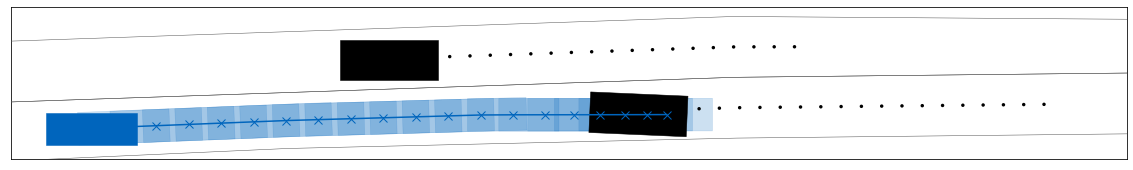

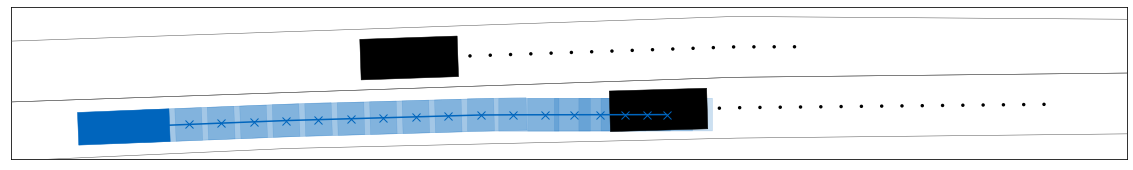

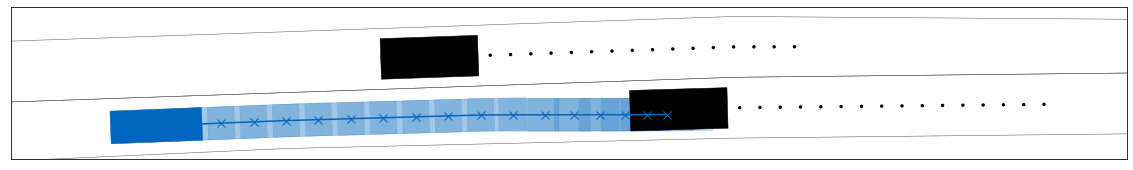

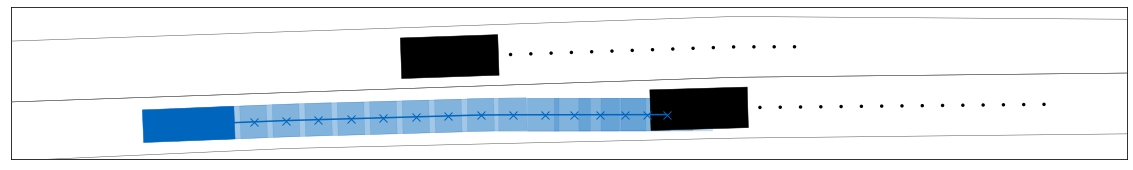

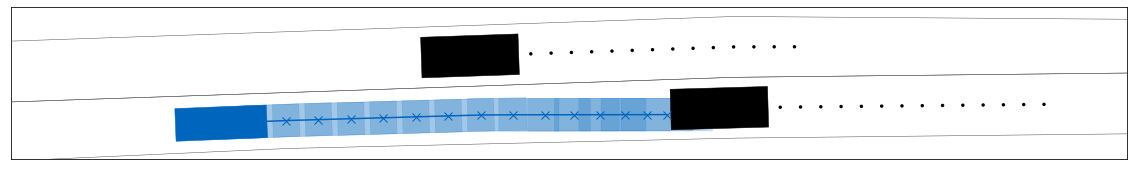

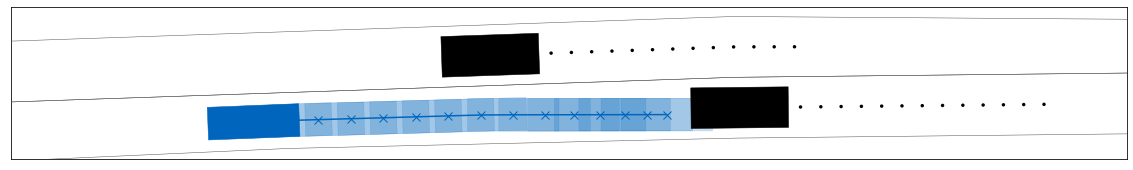

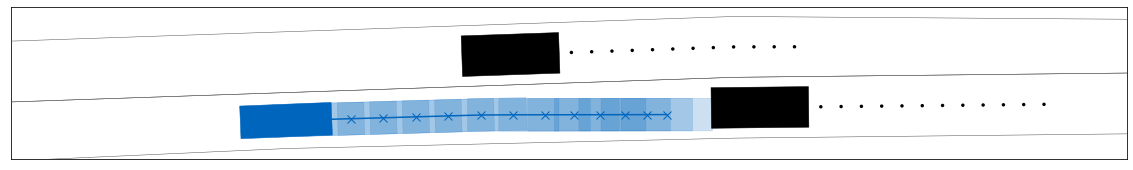

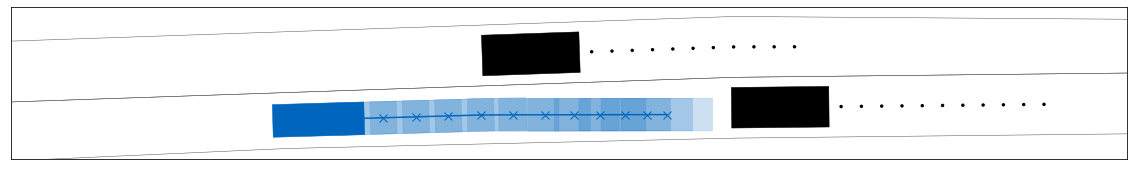

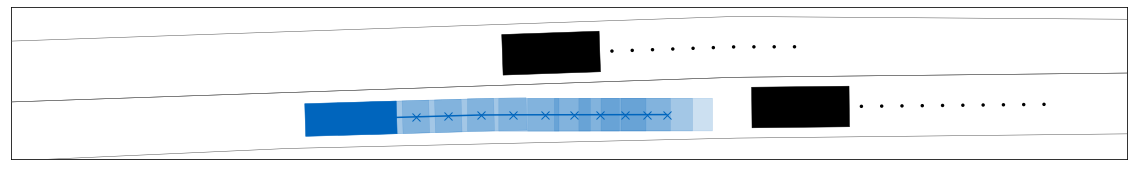

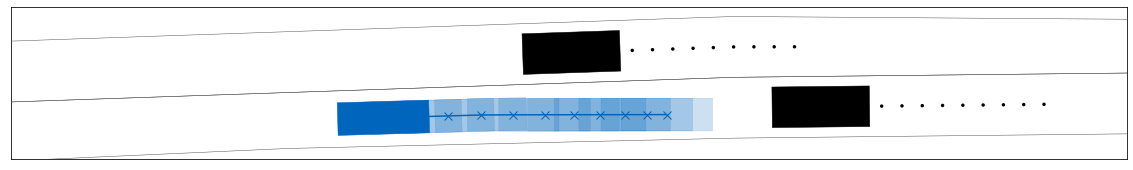

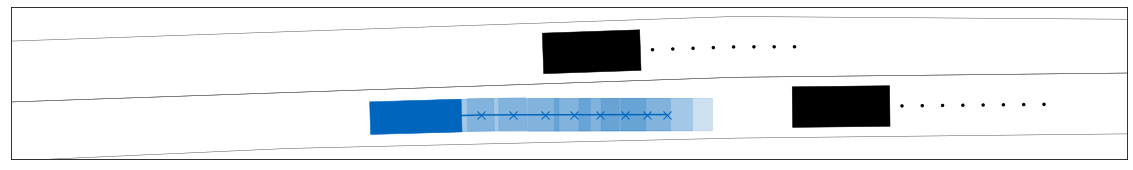

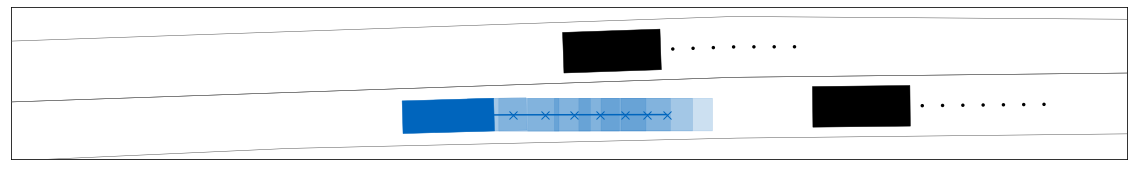

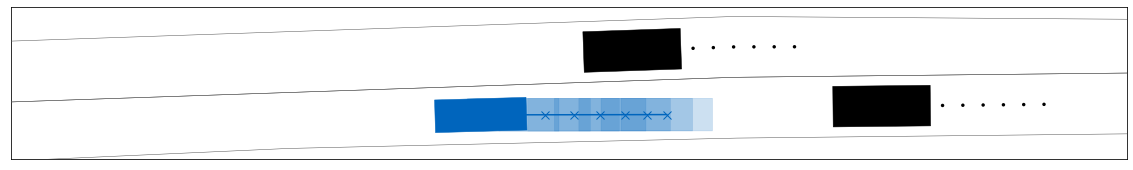

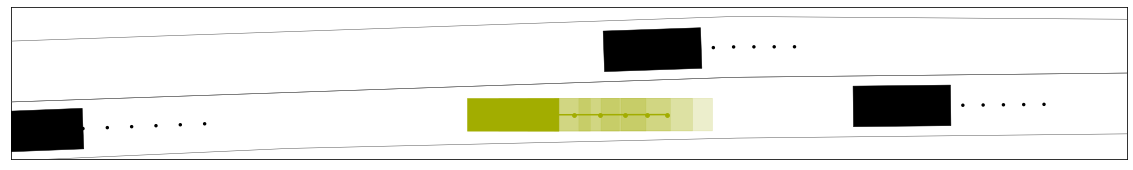

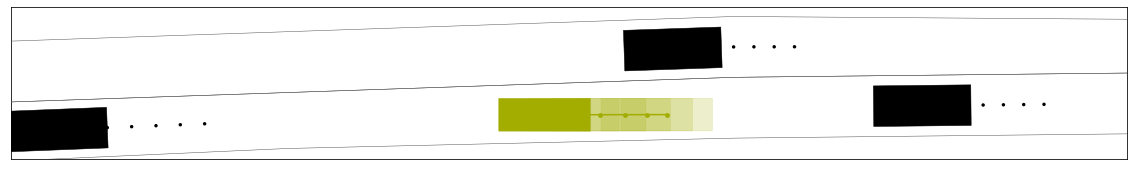

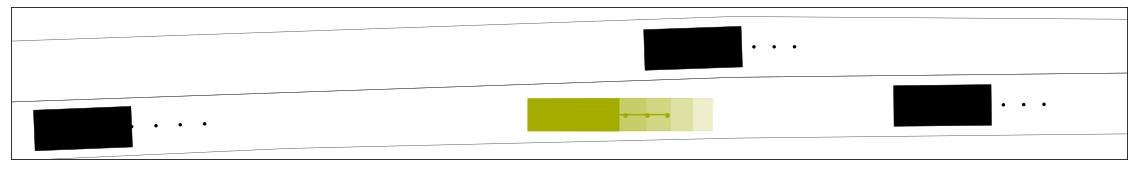

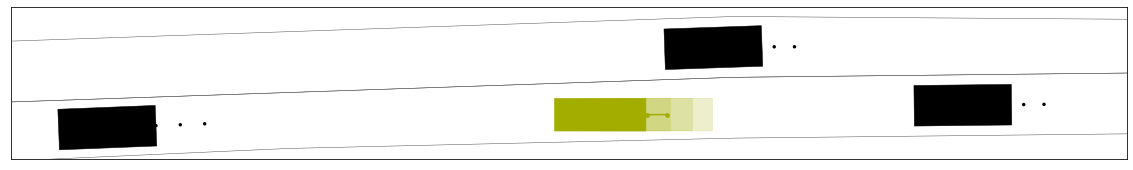

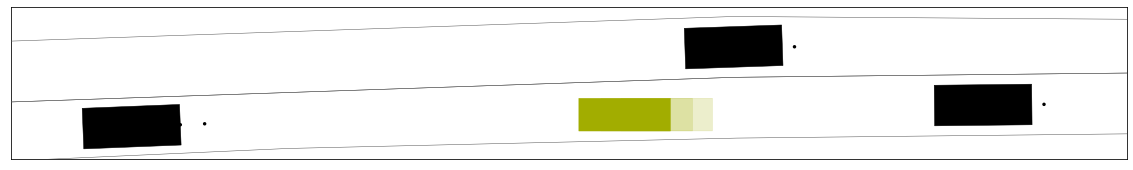

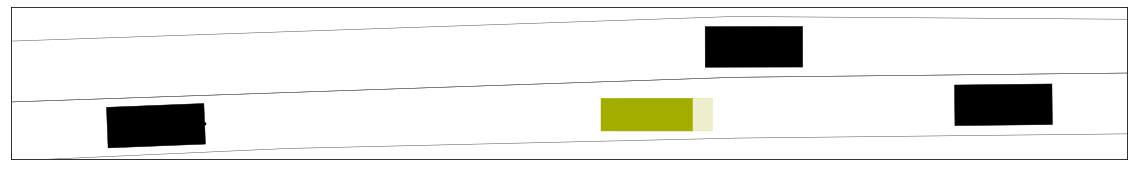

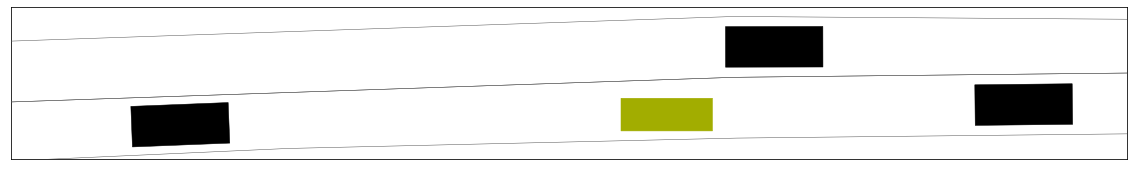

In [43]:
from commonroad_repair.crrepairer.repairer.visualization import visualize_repairing_result

for time_step in range(ego_vehicle.prediction.final_time_step + 1):
    visualize_repairing_result(scenario,
                               ego_vehicle,
                               time_step,
                               plot_limits=plot_limits,
                               tc=repairer.tc)